In [1]:
import os
import sys
import joblib
import re
import random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Metadata

## флаги отладки, ускоряющие повторный прогон
**NB!:** при полном прогоне все флаги установлены в `True`

In [2]:
running_in_cloud = False           # финальный прогон будет на VM в облаке без выполнения локальных сейвов
download_wikitext = False          # выбор источника датасета - интернет ресурсы библиотеки или локальный сейв
run_LSTM_model = False
run_GRU_model = True

## глобальные параметры выполнения кода

In [3]:
# Фиксируем seed для воспроизводимости
random.seed(42)
torch.manual_seed(42)


seq_len_thres = 32             # длина последовательности токенов в объектах модели, на которых будет инференс
vocab_len_thres = 70000        # задаваемая длина словаря наиболее частых токенов-слов в корпусе текстов
learning_rate = 0.001
nof_epochs = 7

# Этап 1.  Загрузка и подготовка данных


## loading dataset

In [4]:

if download_wikitext:
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1")
    if not running_in_cloud:
        joblib.dump(dataset, os.path.join('.','data','wikitext2dataset.joblib'))
else:
    if running_in_cloud:
        sys.exit(
    'FYI: debug flags mismatch: you are supposed to load data from the net when rinning in the cloud')
    else:
        dataset = joblib.load(os.path.join('.','data','wikitext2dataset.joblib'))

## first look at data

In [5]:
dataset

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

In [6]:
dataset['train']

Dataset({
    features: ['text'],
    num_rows: 36718
})

In [7]:
print(type(dataset['train']['text']))                    # проверим тип данных
print('='*80, '\n')

print(dataset['train']['text'][:5])                      # топ списка
print('='*80, '\n')
      
for i, s in enumerate(dataset['train']['text'][:5]):   # выведем поэлементно с нумерацией
    if len(s) == 0:
        print(i, '  ', '<empty string>')                 # сделаем видимыми пустые строки
    else:
        print(i, '  ', s)
print('='*80, '\n')

for i, s in enumerate(dataset['train']['text'][:10]):
    s = s.strip('\n').strip()                        # похоже, строки списка содержат "\n" на конце и пробелы
    if len(s) == 0:
        print(i, '  | len in words =', str(len(s.split())).rjust(3), '|  ', '<empty string>')
    else:
        print(i, '  | len in words =', str(len(s.split())).rjust(3), '|  ', s)

<class 'list'>

['', ' = Valkyria Chronicles III = \n', '', ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n', " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the

## len-EDA

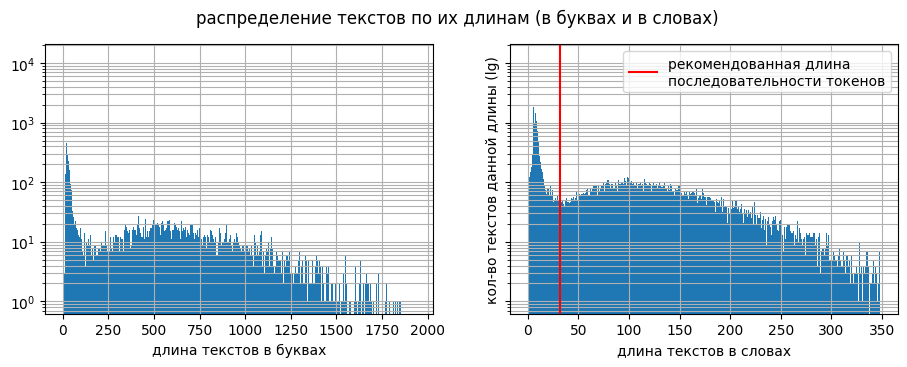

In [8]:
len_in_chars = [ len(el) for el in dataset['train']['text'] ]
len_in_words = [ len(el.split()) for el in dataset['train']['text'] ]

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(11,3.5), sharey=True)

ax1.hist(len_in_chars, bins=range(max(len_in_chars)//2))
ax1.set_yscale('log')
ax1.grid(which='both')
ax1.set_xlabel('длина текстов в буквах')

ax2.hist(len_in_words, bins=range(max(len_in_words)//2))
ax2.set_yscale('log')
ax2.grid(which='both')
ax2.set_xlabel('длина текстов в словах')
ax2.set_ylabel('кол-во текстов данной длины (lg)')
ax2.axvline(seq_len_thres, color='red', label='рекомендованная длина\nпоследовательности токенов')
ax2.legend(loc='upper right')

fig.suptitle('распределение текстов по их длинам (в буквах и в словах)')
plt.show()

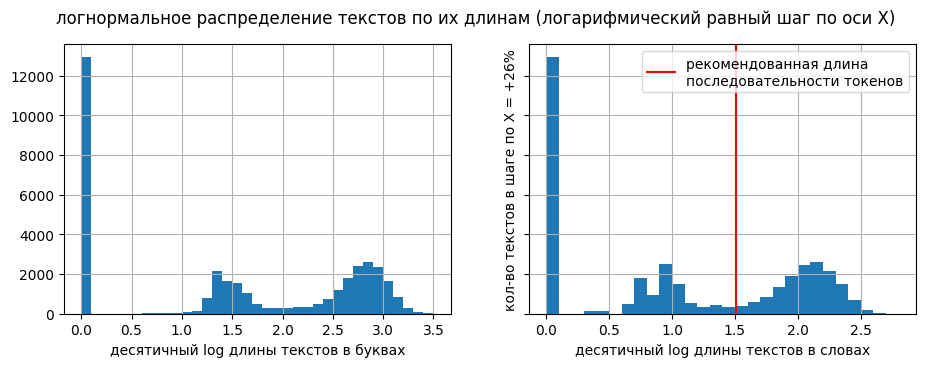

In [9]:
lg_len_in_chars = np.log(np.array(len_in_chars)+1) / np.log(10)   # если убрать прибавление 1, то код будет работать,
lg_len_in_words = np.log(np.array(len_in_words)+1) / np.log(10)   # но полностью исчезнет нулевая мода на графиках

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(11,3.5), sharey=True)

ax1.hist(lg_len_in_chars, bins=[ 0.1*i for i in range(int(max(lg_len_in_chars)*10)+1)] )
ax1.grid(which='both')
ax1.set_xlabel('десятичный log длины текстов в буквах')

ax2.hist(lg_len_in_words, bins=[ 0.1*i for i in range(int(max(lg_len_in_words)*10)+1)] )
ax2.grid(which='both')
ax2.set_xlabel('десятичный log длины текстов в словах')
ax2.set_ylabel('кол-во текстов в шаге по X = +'+str(round((10**0.1-1)*100))+'%')
ax2.axvline(np.log(seq_len_thres)/np.log(10), color='red', label='рекомендованная длина\nпоследовательности токенов')
ax2.legend(loc='upper right')

fig.suptitle('логнормальное распределение текстов по их длинам (логарифмический равный шаг по оси X)')
plt.show()

**ВЫВОДЫ ИЗ ГРАФИКОВ:**
* В логнормальных координатах отчетливо выявляются три моды текстов:
  * совсем короткие, практически все они просто пустые
  * короткие - порядка десятка слов
  * полные - порядка сотни слов и длиннее
* `np.log(x)` справляется и с нулевым аргументом, выдавая минус бесконечность, которую не отрисует `matplotlib`, но мы добавляли к x +1 под логарифмом - чтобы вернуть на график все тексты.
* Рекомендуемая длина последовательности токенов 32 при предлагаемой токенизации словами идеально фильтрует только последнюю моду, удаляя две другие как шум - что разумно, так как статистика (и логика за ней) фразообразования в каждой моде, скорее всего, разная:  примерно также, как статистика продолжения фразы на заборе сильно отличается от таковой в художественном романе!

## raw preprocessing
теперь, когда минимальную длину текста в словах мы обосновали, можно проводить большую чистку данных 

In [10]:
def raw_preproc(raw_texts_list, len_thres):
    # удаляем слишком короткие тексты
    texts = [line for line in raw_texts_list if len(line.split()) >= len_thres]

    # функция для "чистки" текстов (из материалов урока)
    def clean_string(text):
        # приведение к нижнему регистру
        text = text.lower()
        # удаление всего, кроме латинских букв, цифр и пробелов
        text = re.sub(r'[^a-z0-9\s]', '', text)
        # удаление дублирующихся пробелов, удаление пробелов по краям
        text = re.sub(r'\s+', ' ', text).strip()
    
        return text

    # "чистим" тексты
    cleaned_texts_list = list(map(clean_string, texts))
    # повторно "обрезаем" коротких
    return [line for line in cleaned_texts_list if len(line.split()) >= len_thres]

### применяем функцию чистки к train/val/test спискам текстов

In [11]:
train_texts = raw_preproc(dataset['train']['text'], seq_len_thres)  
test_texts = raw_preproc(dataset['test']['text'], seq_len_thres)
val_texts = raw_preproc(dataset['validation']['text'], seq_len_thres)

len(train_texts), len(val_texts), len(test_texts)

(14344, 1519, 1726)

### оцениваем потери в данных после очистки

In [12]:
print('Осталось после чистки текстов:')
print('='*30)
print('train      ','val        ','test')
print('-'*30)
print(round(len(train_texts) / len(dataset['train']) *100,1), '%     ',
      round(len(val_texts) / len(dataset['validation']) *100,1), '%     ',
      round(len(test_texts) / len(dataset['test']) *100,1), '%')

Осталось после чистки текстов:
train       val         test
------------------------------
39.1 %      40.4 %      39.6 %


In [13]:
for i, s in enumerate(train_texts[:10]):
    print(i, '  | len =', str(len(s.split())).rjust(3), '|  ', s)

0   | len = 107 |   senj no valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and mediavision for the playstation portable released in january 2011 in japan it is the third game in the valkyria series employing the same fusion of tactical and real time gameplay as its predecessors the story runs parallel to the first game and follows the nameless a penal military unit serving the nation of gallia during the second europan war who perform secret black operations and are pitted against the imperial unit calamaty raven
1   | len =  82 |   the game began development in 2010 carrying over a large portion of the work done on valkyria chronicles ii while it retained the standard features of the series it also underwent multiple adjustments such as making the game more forgiving for series newcomers character designer raita honjou and composer hitosh

## собираем словарь для токенизации словами
для словаря не помешает объединить все данные

In [14]:
corpus = train_texts + val_texts + test_texts

counter = Counter()

for text in corpus:
    counter.update(text.split())

# список слов в порядке убывания частоты
words = [word for word, freq in counter.most_common()]

# список частот в том же порядке
freqs = [freq for word, freq in counter.most_common()]

print('Full dictionary length for word-tokenization was', len(freqs))
print('Top10 most frequent tokens are:', words[:10])

Full dictionary length for word-tokenization was 70075
Top10 most frequent tokens are: ['the', 'of', 'and', 'in', 'to', 'a', 'was', 'on', 'as', 'that']


### посмотрим как словарь распределился по частотам

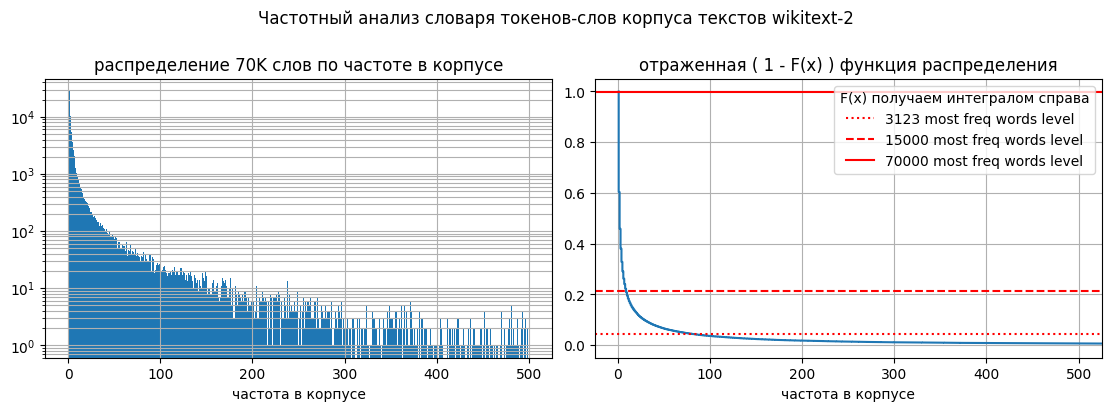

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharex=True, layout='constrained')

ax1.hist( freqs, bins=range(500) )
ax1.set_yscale('log')
ax1.grid(which='both')
ax1.set_title('распределение 70K слов по частоте в корпусе')
ax1.set_xlabel('частота в корпусе')

ax2.plot(freqs, [i/len(freqs) for i in range(1, len(freqs)+1)] )
ax2.axhline(3123/len(freqs), color='red', ls=':', label='3123 most freq words level')
ax2.axhline(15000/len(freqs), color='red', ls='--', label='15000 most freq words level')
ax2.axhline(vocab_len_thres/len(freqs), color='red', label=str(vocab_len_thres)+' most freq words level')
ax2.set_xlim(-25,525)
ax2.grid()
ax2.legend(title='F(x) получаем интегралом справа', loc='upper right')
ax2.set_title('отраженная ( 1 - F(x) ) функция распределения')
ax2.set_xlabel('частота в корпусе')

fig.suptitle('Частотный анализ словаря токенов-слов корпуса текстов wikitext-2\n')
plt.show()

**ВЫВОДЫ ИЗ ГРАФИКОВ:**
* 30К слов из 70К встречаются во всем корпусе только 1 раз!
* 80% слов встречаются во всем корпусе реже 10 раз и навряд ли могут быть индивидуально запомнены моделью
* но замена их всех на OoV-токен сделает этот токен невероятно частым и он может начать попадать в рекомендации
* поэтому хотелось бы сделать его более естественно выглядящим в рекомендации модели - этакий джокер или слово-паразит: "типа", "этахрень", "well", "voila", "imho"

проверим "voila" - подойдет: его нет в корпусе!

In [16]:
'voila' in words, 'voil' in words       # слово могло обрезать французское написание последней буквы "voil`a"

(False, False)

### подбираем оптимальную отсечку по частоте (NB!: позднее корректируется!)
идея та же, что в оптимальном балансе precision-recall через максимум метрики f1

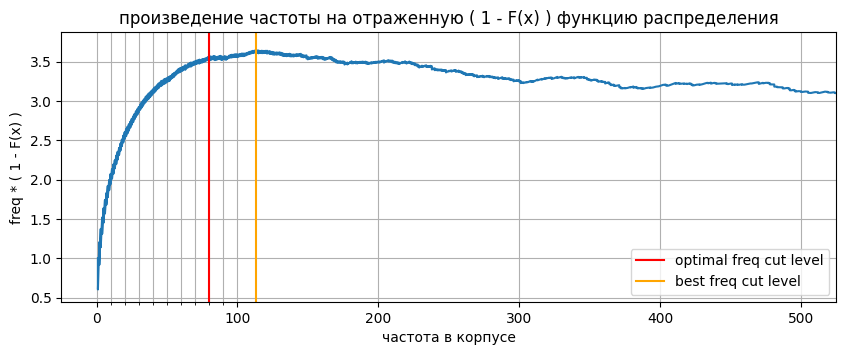

In [17]:
plt.figure(figsize=(10,3.5))
plt.plot(freqs, np.array(freqs) * np.array([i/len(freqs) for i in range(1, len(freqs)+1)]) )
plt.axvline(80, color='red', label='optimal freq cut level')
plt.axvline(113, color='orange', label='best freq cut level')
plt.xlim(-25,525)
plt.xticks(range(0,100,10), minor=True)
plt.grid(which='both')
plt.legend(loc='lower right')
plt.title('произведение частоты на отраженную ( 1 - F(x) ) функцию распределения')
plt.ylabel('freq * ( 1 - F(x) )')
plt.xlabel('частота в корпусе')


plt.show()

**ВЫВОДЫ ИЗ ГРАФИКА:**
* максимум площади под графиком отраженной функции распределения достигается при freq = 113
* однако, там широкое плато, поэтому за оптимальную отсечку принимаем частоту 80, где площадь начинает уже уверенно деградировать

In [18]:
print('Оптимальная длина словаря на данном корпусе текстов:   vocab_len_thres =', len([f for f in freqs if f >= 80]))

Оптимальная длина словаря на данном корпусе текстов:   vocab_len_thres = 3123


**ЗАМЕЧАНИЯ ПО БОЛЕЕ ПОЗДНИМ КОРРЕКЦИЯМ**
* указанная проблема, что в текстах очень большой словарный запас и большая часть слов используется редко и с синонимами не позволяет эффективно использовать OoV-токен, так как его доля получается проценты и даже десятки процентов - в любом случае модель будет обучаться на тривиальную, которая просто предсказывает voila всегда, так как естественный рейт OoV-токена выше точности модели, сколько не обучай
* так что в итоге взяли размер словаря 70К
* забавный момент - указывает на природу популярности слов-паразитов у людей с невысоким интеллектом!

### ну и собственно словари: `words_encoder` & `words_decoder`

In [19]:
print('FYI: actual vocab_len_thres is set to:', vocab_len_thres)

FYI: actual vocab_len_thres is set to: 70000


In [20]:
words_encoder = dict(zip(words[:vocab_len_thres], range(vocab_len_thres)))
words_decoder = dict(zip(range(vocab_len_thres), words[:vocab_len_thres]))

# добавим voila
words_encoder['voila'] = vocab_len_thres
words_decoder[vocab_len_thres] = 'voila'

## texts encoding & "voila" substitution for OoV-words

### сперва нужно сделать замену редких на "voila"

In [21]:
black_list = set(words[vocab_len_thres:])

voila_train_texts, voila_val_texts, voila_test_texts = [], [], []
data_type = ['train data','val data','test data']

for i, (output, input) in enumerate([(voila_train_texts, train_texts),  
                                     (voila_val_texts, val_texts),      
                                     (voila_test_texts, test_texts)]):  
    print('Handling', data_type[i])
    
    for s in input:
        new_s_list = []
        for w in s.split():
            if w in black_list:
                new_s_list.append('voila')
            else:
                new_s_list.append(w)
        output.append(' '.join(new_s_list))
    
print('FYI: all done!')


len(voila_train_texts), len(voila_val_texts), len(voila_test_texts)

Handling train data
Handling val data
Handling test data
FYI: all done!


(14344, 1519, 1726)

### проверим, не много ли voila

In [22]:
for i in range(8):
    print(i, '  | len =', str(len(train_texts[i].split())).rjust(4), '|  ', train_texts[i])
    print(i, '  | len =', str(len(voila_train_texts[i].split())).rjust(4), '|  ', voila_train_texts[i])
    print('-'*80)

0   | len =  107 |   senj no valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and mediavision for the playstation portable released in january 2011 in japan it is the third game in the valkyria series employing the same fusion of tactical and real time gameplay as its predecessors the story runs parallel to the first game and follows the nameless a penal military unit serving the nation of gallia during the second europan war who perform secret black operations and are pitted against the imperial unit calamaty raven
0   | len =  107 |   senj no valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and mediavision for the playstation portable released in january 2011 in japan it is the third game in the

**ВЫВОДЫ**
* здесь пришлось вернуться и откорректировать порог отсечки: причина в том, что тексты написаны хорошим языком, с использованием синонимов и широкого набора терминов (обладателями словарного запаса в несколько десятков тысяч слов), поэтому в районе отсечки с частотой 80 еще очень много общеупотребительных слов (nameless, chronicles, tactical, battlefield, scouts, soldier, switch и т.д.) попадает в OoV-токен
* перенеся порог с 3К до 15К слов, мы понизили порог отсечки по частоте до 10
* при новом пороге 15К видим, что voila заменяют либо редкие слова (senj(o), unrecorded, gallian, echelons, 422), либо ошибки в написании (europen, valkyira, shocktrupper) 
* строго говоря, хорошо бы помимо формальной предобработки провести еще схлопывание синонимов (для повышения частотности) и коррекцию орфографических ошибок (для того же) - тогда хватило бы и 5К и обучение было бы более уверенным.  А так для слов с частотой 10 обучение обещает быть слабым!
* однако и 15К оказалось на практике плохо - дело в том, что если закодировать 70К - 15К = 55К слов одним OoV-токеном, то модель будет самообучаться на предпочтительное предсказание только его: слишком велик естественный рейт у одного варианта из 15К!

## сборка numpy-массивов из 32-словных последовательностей, заодно и кодирование
Идея сборки словами:
* вытягивать весь список текстов в одну строку и нарезать ее по 32 слова - плохо, так как будет много последовательностей, включающих начало и конец из несвязанных между собой текстов
* поэтому пойдем по-текстно, но при этом будет много хвостов короче 32 слов - что с ними.  Можно просто отбросить, но человеку свойственно в конце абзаца резюмировать мысль, поэтому для последнего отрезка в 32 слов будет отмерять его с конца.

### напишем функцию, которая одновременно делит один текст на фрагменты по 32 слова и делает их кодирование по индексу словаря
и сразу проверим ее работу

In [23]:
def text_to_numpy(text, seq_len = 32):
    idx = 0
    seq_list = []

    encoded_list = [words_encoder[el] for el in text.split()]
    
    while idx + seq_len < len(encoded_list):
        seq_list.append(np.array(encoded_list[idx : idx + seq_len]))
        idx += seq_len
    
    seq_list.append(np.array(encoded_list[-seq_len:]))

    return np.stack(seq_list)

print(voila_train_texts[0])
print('='*70)
print(f'after converting into 32-words sequences and encoding (voila = {vocab_len_thres}):')
text_to_numpy(voila_train_texts[0])

senj no valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and mediavision for the playstation portable released in january 2011 in japan it is the third game in the valkyria series employing the same fusion of tactical and real time gameplay as its predecessors the story runs parallel to the first game and follows the nameless a penal military unit serving the nation of gallia during the second europan war who perform secret black operations and are pitted against the imperial unit calamaty raven
after converting into 32-words sequences and encoding (voila = 70000):


array([[20352,    74,  4342,    80, 22963,  4059,   417,    80,  6243,
         4342,     1,     0,  5313,    80,  1996,   963,     4,     8,
         4342,  4059,   977,   589,   735,    14,     5,  5625,   280,
          582,   245,    60,   405,    13],
       [ 5314,     2, 22964,    11,     0,  1997,  5626,   152,     3,
          210,   358,     3,   735,    17,    14,     0,   222,    60,
            3,     0,  4342,    92,  7778,     0,   150,  4786,     1,
         5625,     2,   763,    48,  2594],
       [    8,    31,  7189,     0,   348,   933,  2877,     4,     0,
           29,    60,     2,  1869,     0, 11005,     5, 16829,   271,
          866,  2014,     0,  1762,     1, 18331,    43,     0,    91,
        26626,    87,    42,  1826,  1649],
       [    2,  1869,     0, 11005,     5, 16829,   271,   866,  2014,
            0,  1762,     1, 18331,    43,     0,    91, 26626,    87,
           42,  1826,  1649,   289,   523,     2,    26, 12118,    99,
            0,  

### используя проверенную функцию соберем все массивы

In [24]:
train_numpy_seq_list, val_numpy_seq_list, test_numpy_seq_list = [], [], []
data_type = ['train data','val data','test data']

for i, (output, input) in enumerate([(train_numpy_seq_list, voila_train_texts),  
                                     (val_numpy_seq_list, voila_val_texts),      
                                     (test_numpy_seq_list, voila_test_texts)]):  
    print('Handling', data_type[i])
    
    for s in input:
        output.append(text_to_numpy(s))

train_numpy_array = np.concatenate(train_numpy_seq_list, axis=0)
val_numpy_array = np.concatenate(val_numpy_seq_list, axis=0)    
test_numpy_array = np.concatenate(test_numpy_seq_list, axis=0)   
    
print('FYI: all done!')


train_numpy_array.shape, val_numpy_array.shape, test_numpy_array.shape

Handling train data
Handling val data
Handling test data
FYI: all done!


((60082, 32), (6312, 32), (7112, 32))

## собираем объекты организации данных для обучения в torch

### наследуем класс torch `Dataset`

In [25]:
class WikiTextDataset(Dataset):
    # в конструкторе просто сохраняем все данные 
    def __init__(self, np_arr):
        self.texts = np.copy(np_arr[:,:-1])
        self.labels = np.copy(np_arr[:,1:])

    # метод __len__ возвращает количество объектов в датасете
    def __len__(self):
        return len(self.texts)

    # метод __getitem__ возвращает элемент датасета с индексом idx
    def __getitem__(self, idx):
        # получаем текст и его класс по индексу
        text = self.texts[idx]
        label = self.labels[idx]
        
        # padding нам не нужен, так как все строки одинаковой длины уже
        mask = np.ones(self.texts.shape)

        # возвращаем текст, маску и класс
        return {
            'input_seq': torch.tensor(text, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long)
        }

### создаем объекты датасетов для всех трех групп train/val/test

In [26]:
train_dataset = WikiTextDataset(train_numpy_array)
val_dataset = WikiTextDataset(val_numpy_array)
test_dataset = WikiTextDataset(test_numpy_array)

### и наконец, создаем загрузчики батчей

In [27]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=512, shuffle=False)


# Этап 2. Реализация и обучение LSTM

## класс LSTM-модели

In [28]:
class WikiTextLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=256, num_layers=2, dropout=0.25):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(input_size=emb_dim, hidden_size=hidden_dim, num_layers=num_layers, 
                            batch_first=True, dropout=dropout, bidirectional=False)
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

        self.init_weights()


    def init_weights(self):
        nn.init.xavier_uniform_(self.fc.weight)
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)


    def forward(self, input_ids):
        x = self.embedding(input_ids)
        lstm_out, _ = self.lstm(x)
        lstm_out_normed = self.norm(lstm_out)
        out = self.dropout(lstm_out_normed)
        logits = self.fc(out)

        return logits

## инстанс модели, оптимизатор и функция потерь

In [29]:
# создание модели
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_lstm = WikiTextLSTM(vocab_size=vocab_len_thres+1).to(device)

# создание оптимизатора и функции потерь
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

## цикл обучения с выделением под-функций

### выделяем код одной эпохи и функцию валидации

In [30]:
# код обучения одной эпохи
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in tqdm(loader):
        ids = batch['input_seq'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(ids)

        # для задачи предсказания следующего слова форма функции потерь модифицируется так:        
        loss = criterion(logits.view(-1, vocab_len_thres+1), labels.view(-1))
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

In [31]:
# код подсчёта accuracy на валидации
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            ids = batch['input_seq'].to(device)
            labels = batch['label']
            logits = model(ids)

            # для задачи предсказания следующего слова форма функции потерь модифицируется так:
            loss = criterion(logits.view(-1, vocab_len_thres+1), labels.view(-1))
            
            total_loss += loss.item()
    return total_loss / len(loader), np.exp(total_loss / len(loader))

### сам цикл

In [32]:
# обучение
lstm_train_history = []
if run_LSTM_model:
    for epoch in range(nof_epochs):
        epoch_start = datetime.now()
        train_loss = train_epoch(model_lstm, train_dataloader, optimizer_lstm)
        val_loss, perp = evaluate(model_lstm, val_dataloader)
        epoch_stop = datetime.now()
        
        lstm_train_history.append((train_loss, val_loss, perp, round((epoch_stop-epoch_start).total_seconds())))
        
        print(f"Epoch {epoch+1}:  ", 
              f"Avg via epoch Train Loss = {train_loss:.4f} | ", 
              f"Final epoch end Val Loss = {val_loss:.4f} | ", 
              f"Perplexity = {perp:.4f}")
        
        if not running_in_cloud:            # будем сохранять модель после каждой эпохи для early stopping 
            torch.save(model_lstm.state_dict(), os.path.join('.','models','lstm_model_dict_epoch_'+str(epoch)+'.save'))
            joblib.dump(lstm_train_history, os.path.join('.','models','lstm_train_history_epoch_'+str(epoch)+'.save'))
else:
    if running_in_cloud:
        sys.exit('FYI: debug flags mismatch: you are not supposed to save/load models when rinning in the cloud')
    else:
        model_lstm.load_state_dict(torch.load(os.path.join('.','models','lstm_model_dict_epoch_4.save')))
        lstm_train_history = joblib.load(os.path.join('.','models','lstm_train_history_epoch_6.save'))
        
        for epoch in range(len(lstm_train_history)):
            train_loss, val_loss, perp, epoch_runtime = lstm_train_history[epoch]
            print(f"Epoch {epoch+1} run {epoch_runtime} seconds:  ", 
                  f"Avg via epoch Train Loss = {train_loss:.4f} | ", 
                  f"Final epoch end Val Loss = {val_loss:.4f} | ", 
                  f"Perplexity = {perp:.4f}")

Epoch 1 run 1531 seconds:   Avg via epoch Train Loss = 7.5513 |  Final epoch end Val Loss = 7.0744 |  Perplexity = 1181.3098
Epoch 2 run 1536 seconds:   Avg via epoch Train Loss = 6.7384 |  Final epoch end Val Loss = 6.9350 |  Perplexity = 1027.6228
Epoch 3 run 1561 seconds:   Avg via epoch Train Loss = 6.3963 |  Final epoch end Val Loss = 6.9329 |  Perplexity = 1025.4437
Epoch 4 run 1529 seconds:   Avg via epoch Train Loss = 6.1602 |  Final epoch end Val Loss = 6.9210 |  Perplexity = 1013.2957
Epoch 5 run 1547 seconds:   Avg via epoch Train Loss = 5.9602 |  Final epoch end Val Loss = 6.9031 |  Perplexity = 995.3251
Epoch 6 run 1523 seconds:   Avg via epoch Train Loss = 5.7809 |  Final epoch end Val Loss = 6.9159 |  Perplexity = 1008.1938
Epoch 7 run 1533 seconds:   Avg via epoch Train Loss = 5.6192 |  Final epoch end Val Loss = 6.9380 |  Perplexity = 1030.7180


**ВЫВОДЫ:**
* переобучение начинается после 5й эпохи, поэтому за лучшую модель выбираем сейв от 5й эпохи
* неопределенность выбора ответа сузилась от 70К до 1К, но все равно этого не достаточно для бизнес кейса персонального Т9
* можно порекомендовать в реализацию начало показа подсказки после первой введенной буквы нового слова - тогда количество вариантов падает в 25 раз, ужимая perplexity на уровень 40

## оценим результаты визуально

In [33]:
X_val = val_numpy_array[:512,:-1]
y_val = val_numpy_array[:512,1:]

model_lstm.eval()

WikiTextLSTM(
  (embedding): Embedding(70001, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.25)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc): Linear(in_features=256, out_features=70001, bias=True)
)

In [34]:
y_pred = np.argmax(model_lstm(torch.tensor(X_val, dtype=torch.long)).detach().numpy(), axis=2)

In [35]:
view_df = pd.DataFrame(
             index=['actual word in text', 'word suggested by model'],
             data=[
                   list(y_val.flatten()),
                   list(y_pred.flatten())
    ]
).T

for col in view_df.columns:       # а теперь декодируем номера классов обратно в слова
    view_df[col] = view_df[col].map(lambda n: words_decoder[n] if n >= 0 else 'NA')

view_df['full match'] = view_df['actual word in text'] == view_df['word suggested by model']

print(' '*12, 'ONE TEXT FROM VALIDATION DATASET:')
view_df.head(31)                  # развернем первую последовательность вертикально

             ONE TEXT FROM VALIDATION DATASET:


,actual word in text,word suggested by model,full match
0,gammarus,and,False
1,known,the,False
2,as,as,True
3,the,the,True
4,european,sun,False
5,lobster,union,False
6,or,and,False
7,common,the,False
8,lobster,starlings,False
9,is,is,True


**ВЫВОДЫ:**
* модель неплохо справляется в предиктом типичных связок предлогов, союзов, артиклей и даже клише:
  * known -> as the
  * it -> is a
  * parts -> of the
  * is -> a
  * from -> the
  * species -> of
  * european -> union (тут, правда, не угадала - текст про лобстеров, а не про политиков, но клише понятно!)
* хотя для практического юзкейса подсказок петимотов (petits mots) маловато, но сам факт, что вот так за два с половиной часа на лаптопе можно обучить мини-мозг базовым связкам языка - это, конечно, впечатляет!
* кстати, поскольку эти маленькие слова являются лидерами по частотности, то accuracy получается неплохой для выбора из 70К вариантов ответов - одно попадание на 6 выстрелов !! Это круче чем сомнения perplexity = 1K (в остальных 5 из 6 случаев)
* пример текста вскрывает основную проблему исходного датасета - 14К текстов про что угодно на свете - маловато будет: поэтому тема лобстеров осталась не раскрытой! 

In [36]:
print('Accuracy on the first 512 sequences in the validation dataset =', 
      round(view_df['full match'].mean() *100, 1),'%')

Accuracy on the first 512 sequences in the validation dataset = 15.3 %


# Этап 3. Эксперимент: GRU vs LSTM

## класс GRU-модели

In [37]:
class WikiTextGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=256, num_layers=2, dropout=0.25):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(input_size=emb_dim, hidden_size=hidden_dim, num_layers=num_layers, 
                            batch_first=True, dropout=dropout, bidirectional=False)
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

        self.init_weights()


    def init_weights(self):
        nn.init.xavier_uniform_(self.fc.weight)
        for name, param in self.gru.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)


    def forward(self, input_ids):
        x = self.embedding(input_ids)
        gru_out, _ = self.gru(x)
        gru_out_normed = self.norm(gru_out)
        out = self.dropout(gru_out_normed)
        logits = self.fc(out)

        return logits

## инстанс модели, оптимизатор и функция потерь

In [38]:
# создание модели
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_gru = WikiTextGRU(vocab_size=vocab_len_thres+1).to(device)

# создание оптимизатора и функции потерь
optimizer_gru = torch.optim.Adam(model_gru.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

## цикл обучения с переиспользованием ранее выделенных под-функций

In [39]:
# обучение
gru_train_history = []
if run_GRU_model:
    for epoch in range(nof_epochs):
        epoch_start = datetime.now()
        train_loss = train_epoch(model_gru, train_dataloader, optimizer_gru)
        val_loss, perp = evaluate(model_gru, val_dataloader)
        epoch_stop = datetime.now()
        
        gru_train_history.append((train_loss, val_loss, perp, round((epoch_stop-epoch_start).total_seconds())))
        
        print(f"Epoch {epoch+1}:  ", 
              f"Avg via epoch Train Loss = {train_loss:.4f} | ", 
              f"Final epoch end Val Loss = {val_loss:.4f} | ", 
              f"Perplexity = {perp:.4f}")
        
        if not running_in_cloud:            # будем сохранять модель после каждой эпохи для early stopping 
            torch.save(model_gru.state_dict(), os.path.join('.','models','gru_model_dict_epoch_'+str(epoch)+'.save'))
            joblib.dump(gru_train_history, os.path.join('.','models','gru_train_history_epoch_'+str(epoch)+'.save'))
else:
    if running_in_cloud:
        sys.exit('FYI: debug flags mismatch: you are not supposed to save/load models when rinning in the cloud')
    else:
        model_gru.load_state_dict(torch.load(os.path.join('.','models','gru_model_dict_epoch_4.save')))
        gru_train_history = joblib.load(os.path.join('.','models','gru_train_history_epoch_6.save'))
        
        for epoch in range(len(gru_train_history)):
            train_loss, val_loss, perp, epoch_runtime = gru_train_history[epoch]
            print(f"Epoch {epoch+1} run {epoch_runtime} seconds:  ", 
                  f"Avg via epoch Train Loss = {train_loss:.4f} | ", 
                  f"Final epoch end Val Loss = {val_loss:.4f} | ", 
                  f"Perplexity = {perp:.4f}")

100%|██████████| 939/939 [25:14<00:00,  1.61s/it]


Epoch 1:   Avg via epoch Train Loss = 7.5461 |  Final epoch end Val Loss = 7.0915 |  Perplexity = 1201.7685


100%|██████████| 939/939 [25:11<00:00,  1.61s/it]


Epoch 2:   Avg via epoch Train Loss = 6.7439 |  Final epoch end Val Loss = 6.9834 |  Perplexity = 1078.5286


100%|██████████| 939/939 [24:59<00:00,  1.60s/it]


...

Epoch 5:   Avg via epoch Train Loss = 5.9054 |  Final epoch end Val Loss = 6.9231 |  Perplexity = 1015.4374


100%|██████████| 939/939 [24:54<00:00,  1.59s/it]


Epoch 6:   Avg via epoch Train Loss = 5.7170 |  Final epoch end Val Loss = 6.9593 |  Perplexity = 1052.9157


100%|██████████| 939/939 [25:00<00:00,  1.60s/it]


Epoch 7:   Avg via epoch Train Loss = 5.5533 |  Final epoch end Val Loss = 7.0049 |  Perplexity = 1102.0699
